<a href="https://colab.research.google.com/github/LuisFelipeVelasco/Generative_AI_Experiments/blob/main/text_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**LIBRARIES IMPORTATION**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

# **CALCULATING PROBABILITY OF characters_ASCII IN A TEXT**

**CHARGING TEXT**

In [193]:
!wget https://raw.githubusercontent.com/LuisFelipeVelasco/Generative_AI_Experiments/refs/heads/main/text.txt

--2026-06-06 18:50:02--  https://raw.githubusercontent.com/LuisFelipeVelasco/Generative_AI_Experiments/refs/heads/main/text.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9977 (9.7K) [text/plain]
Saving to: ‘text.txt.1’

text.txt.1          100%[===================>]   9.74K  --.-KB/s    in 0s      

2026-06-06 18:50:02 (75.0 MB/s) - ‘text.txt.1’ saved [9977/9977]



**READING TEXT**

In [292]:
with open('text.txt', 'r') as file:
    content = file.read()
    print(content)

There is a story that runs beneath every calculation ever performed, beneath every line of code ever written, beneath every theorem ever proved. It is a story about the human need to count, to measure, to predict, and ultimately to build machines that can do all of these things faster and more reliably than any single mind. That story begins not in a university lecture hall or a computing laboratory, but in the mud and grain of ancient river valleys, where the earliest civilisations discovered that the world could be made to yield its secrets if only one found the right way to ask. Mathematics and computer science are often treated as distinct disciplines today, separated by departments and journals and professional identities. Yet the deeper one digs into the history of either field, the more clearly one sees that they are two expressions of the same underlying impulse: the desire to reduce complexity to pattern, and to harness pattern for practical ends.The earliest unambiguous evide

**CALCULATING THE PROBABILITY OF EACH CHARACTER**

In [461]:
#convert all the text in lowercase
content=content.lower()
#become each character into it´s ASCII code to work with numpy
characters_ASCII=np.array([ord(char) for char in content])
#Remove \n character
characters_ASCII=np.delete(characters_ASCII,np.where(characters_ASCII==10))
#Calculate the probabilities:
print(len(characters_ASCII))
unique_chars,char_frequencies=np.unique(characters_ASCII,return_counts=True)
probability_chars=(char_frequencies*100)/len(characters_ASCII)
print(probability_chars)


9974
[1.49689192e+01 3.00782033e-02 9.72528574e-01 1.20312813e-01
 5.71485863e-01 8.02085422e-02 9.02346100e-02 1.00260678e-02
 4.01042711e-02 3.00782033e-02 2.00521356e-02 2.00521356e-02
 2.00521356e-02 3.00782033e-02 8.02085422e-02 8.02085422e-02
 1.00260678e-02 6.93803890e+00 1.39362342e+00 3.25847203e+00
 2.86745538e+00 9.97593744e+00 1.57409264e+00 1.55404051e+00
 3.70964508e+00 6.29637056e+00 6.01564067e-02 2.60677762e-01
 3.80990575e+00 2.73711650e+00 6.22618809e+00 6.07579707e+00
 1.80469220e+00 1.50391017e-01 4.84259074e+00 4.91277321e+00
 8.04090636e+00 2.48646481e+00 8.52215761e-01 1.14297173e+00
 2.10547423e-01 1.58411871e+00 5.01303389e-02 1.00260678e-02]


**GRAPHING PROABIBLITIES**

([<matplotlib.axis.YTick at 0x7e0f702fcec0>,
 [Text(0, 0, '0'),
  Text(0, 1, '1'),
  Text(0, 2, '2'),
  Text(0, 3, '3'),
  Text(0, 4, '4'),
  Text(0, 5, '5'),
  Text(0, 6, '6'),
  Text(0, 7, '7'),
  Text(0, 8, '8'),
  Text(0, 9, '9'),
  Text(0, 10, '10'),
  Text(0, 11, '11'),
  Text(0, 12, '12'),
  Text(0, 13, '13'),
  Text(0, 14, '14'),
  Text(0, 15, '15')])

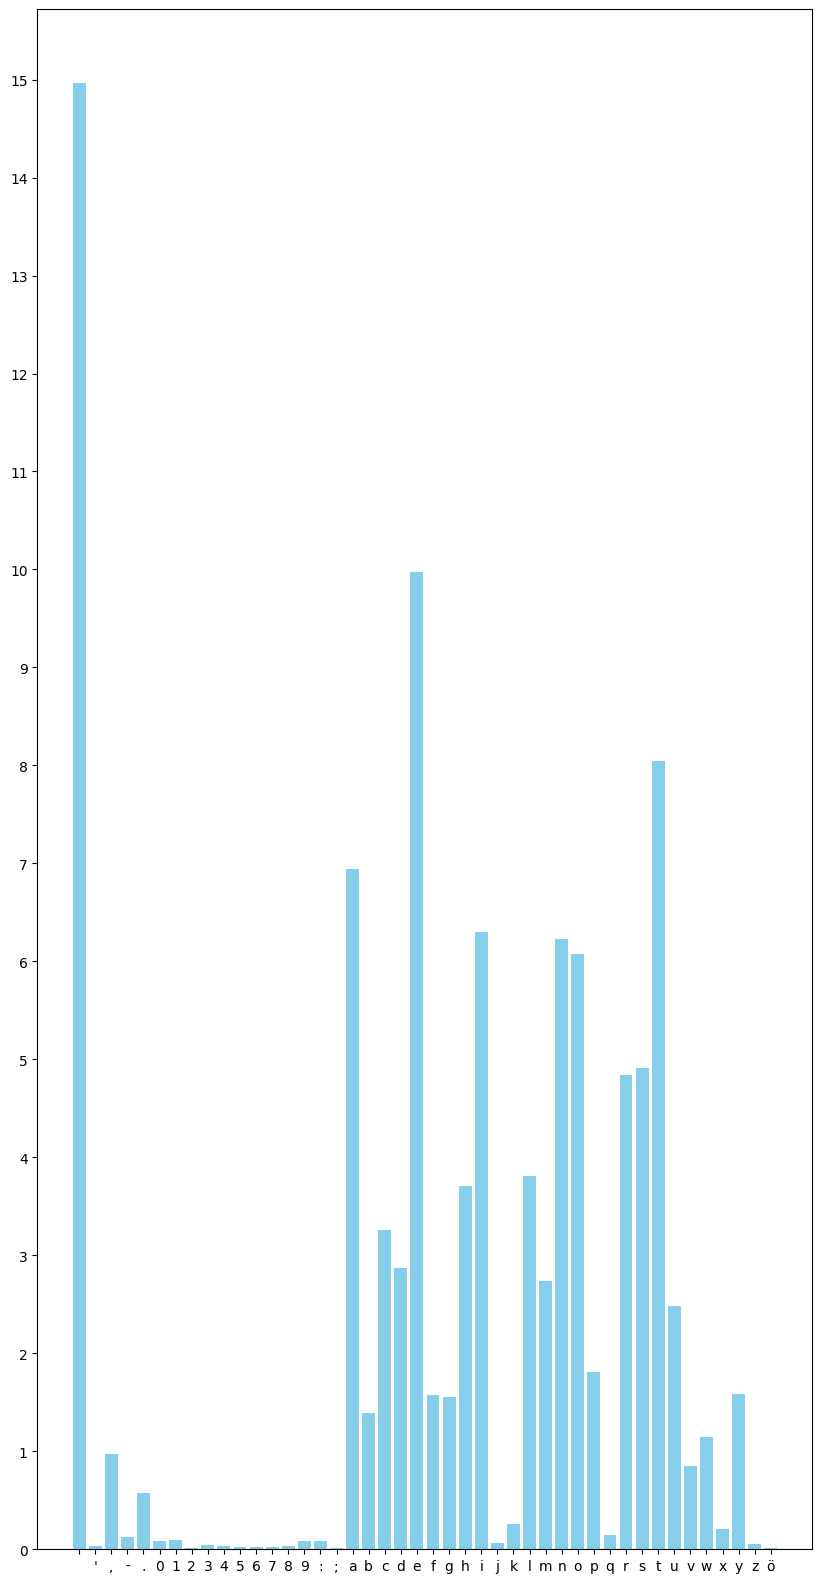

In [471]:
characters=[chr(code) for code in unique_chars]
plt.figure(figsize=(10, 20))
plt.bar(characters, probability_chars, color='skyblue')
plt.yticks(range(0, 16,1))

# **ANALAZYNG CHARACTER PROBABILITY USING RANDOM NUMBERS AND FRECUENCY**  

In [487]:
number_random_numbers=len(characters_ASCII)
max_random_number=len(characters_ASCII)
#Generate a np array with random numbers
random_numbers=np.random.choice(max_random_number,number_random_numbers)
#Generate a np array with the cumulutive sum of char_frecuencies
char_frequencies_sum=np.cumsum(char_frequencies)
#Generate a np array with the index of the char that correspond to each random number
index_char=np.searchsorted(char_frequencies_sum, random_numbers)
char_frequencies_2=np.zeros(len(unique_chars))
unique_index_chars,index_char_frequencies=np.unique(index_char,return_counts=True)
# Map the simulated frequencies back to their absolute character index positions
char_frequencies_2[unique_index_chars] = index_char_frequencies
probability_chars_2=(char_frequencies_2*100)/len(random_numbers)
print(probability_chars_2)

[15.0290756   0.04010427  1.01263285  0.11028675  0.53138159  0.09023461
  0.04010427  0.02005214  0.06015641  0.          0.07018247  0.0300782
  0.02005214  0.05013034  0.09023461  0.04010427  0.02005214  7.05835171
  1.42370162  3.16823742  2.93763786 10.13635452  1.51393623  1.51393623
  4.05053138  6.43673551  0.09023461  0.2807299   3.91016643  2.62682976
  6.69741327  5.55444155  1.5239623   0.14036495  4.99298175  4.70222579
  7.86043714  2.3962302   0.66172047  1.09284139  0.2807299   1.67435332
  0.02005214  0.        ]


**GRAPHING PROBABILITIES**

([<matplotlib.axis.YTick at 0x7e0f6f04f620>,
 [Text(0, 0, '0'),
  Text(0, 1, '1'),
  Text(0, 2, '2'),
  Text(0, 3, '3'),
  Text(0, 4, '4'),
  Text(0, 5, '5'),
  Text(0, 6, '6'),
  Text(0, 7, '7'),
  Text(0, 8, '8'),
  Text(0, 9, '9'),
  Text(0, 10, '10'),
  Text(0, 11, '11'),
  Text(0, 12, '12'),
  Text(0, 13, '13'),
  Text(0, 14, '14'),
  Text(0, 15, '15')])

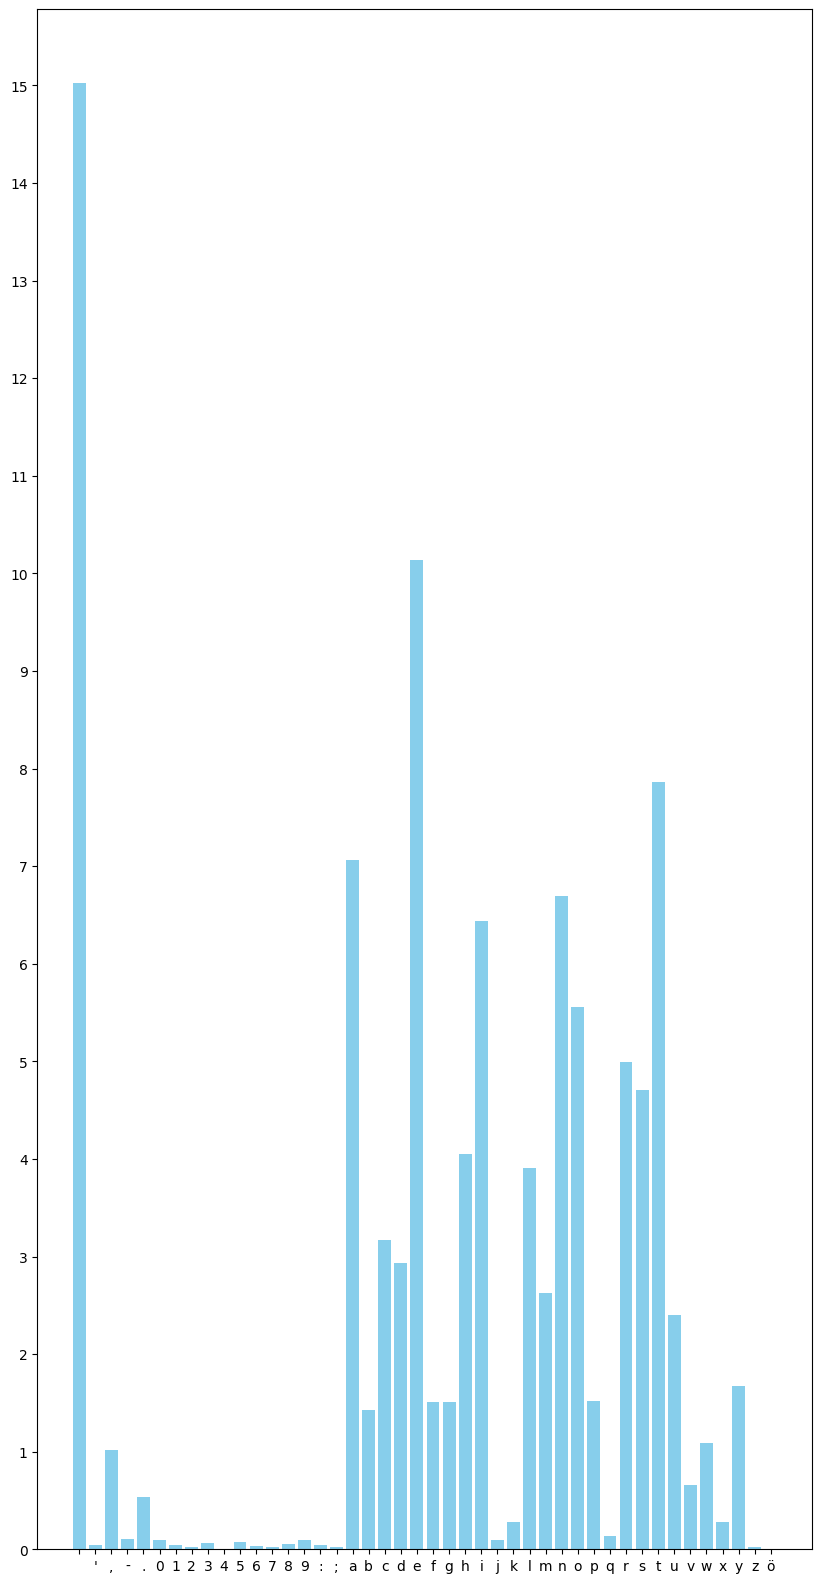

In [488]:
plt.figure(figsize=(10, 20))
plt.bar(characters, probability_chars_2, color='skyblue')
plt.yticks(range(0, 16,1))